<a href="https://colab.research.google.com/github/gigihArmy/Fungi-Image-Classification/blob/main/Edible_and_poisonous_fungi_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fungi Images Classification (Edible & Non-Edible)

In [1]:
!pip install opendatasets

## Library

In [2]:
import os
import opendatasets as od
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax

## Load Datasets

In [3]:
od.download('https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi/data')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: g
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi


100%|██████████| 257M/257M [00:00<00:00, 971MB/s] 


In [4]:
os.listdir('/content/edible-and-poisonous-fungi')

['poisonous sporocarp',
 'poisonous mushroom sporocarp',
 'edible sporocarp',
 'edible mushroom sporocarp']

In [5]:
IMAGE_SHAPE = (224,224)
data_folder_path = '/content/edible-and-poisonous-fungi'

images = []
labels = []

for sub in os.listdir(data_folder_path):
  file_path = os.path.join(data_folder_path, sub)
  for file in os.listdir(file_path):
    img_path = os.path.join(file_path, file)
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, IMAGE_SHAPE)
      images.append(resized)
      if sub.startswith('edible'):
        labels.append(0)
      elif sub.startswith('poisonous'):
        labels.append(1)

images = np.array(images)
labels = np.array(labels) ## 0=edible 1=poisonous

## Pre-processing

In [6]:
#split data train & test
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (2720, 224, 224, 3)
Test set: (681, 224, 224, 3)


In [7]:
#Normalizing
X_train = X_train / 255.0
X_test = X_test / 255.0

## Data Augmentation

In [8]:
data_aug = Sequential([
    layers.RandomFlip('horizontal',
                      input_shape=(224, 224, 3)),
    layers.RandomZoom(0.7),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


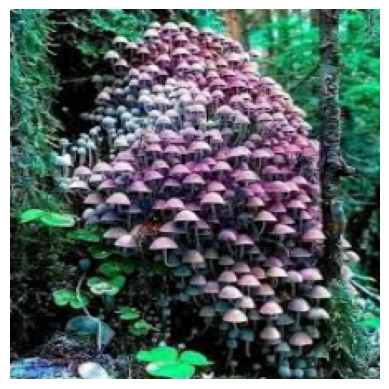

In [9]:
plt.axis('off')
plt.imshow((X_test)[1])

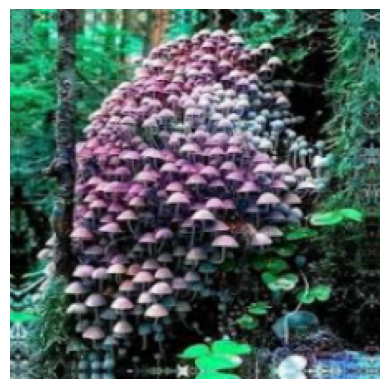

In [10]:
plt.axis('off')
plt.imshow(data_aug(X_test)[1])

## Modelling

In [11]:
cnn = Sequential([
    data_aug,
    #layer 1
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2)),
    #layer 2
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    #layer 3
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,561,633 (21.22 MB)

 Trainable params: 5,561,633 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#model compile
cnn.compile(optimizer=Adamax(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

#callback
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

In [14]:
history = cnn.fit(X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=12,
        batch_size=20,
        callbacks=[callback])

Epoch 1/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.6449 - loss: 0.7289 - val_accuracy: 0.6535 - val_loss: 0.6279
Epoch 2/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6669 - loss: 0.6231 - val_accuracy: 0.6535 - val_loss: 0.6296
Epoch 3/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6622 - loss: 0.6140 - val_accuracy: 0.6579 - val_loss: 0.6401
Epoch 4/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6608 - loss: 0.6050 - val_accuracy: 0.6725 - val_loss: 0.5957
Epoch 5/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6541 - loss: 0.6087 - val_accuracy: 0.6740 - val_loss: 0.5914
Epoch 6/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6522 - loss: 0.6009 - val_accuracy: 0.6711 - val_loss: 0.5957
Epoch 7/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6764 - loss: 0.5907 - val_accuracy: 0.6711 - val_loss: 0.5952
Epoch 8/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6800 - loss: 0.5886 - val_acc

In [19]:
cnn.save('cnn_model.keras')

## Model Evaluation

In [15]:
cnn.evaluate(X_test, y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6695 - loss: 0.5879


[0.5666263699531555, 0.685756266117096]

In [16]:
y_pred = cnn.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_classes, target_names=['edible', 'poisonous']))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

      edible       0.58      0.33      0.42       236
   poisonous       0.71      0.87      0.78       445

    accuracy                           0.69       681
   macro avg       0.65      0.60      0.60       681
weighted avg       0.67      0.69      0.66       681



Text(0.5, 1.0, 'Confusion Matrix')

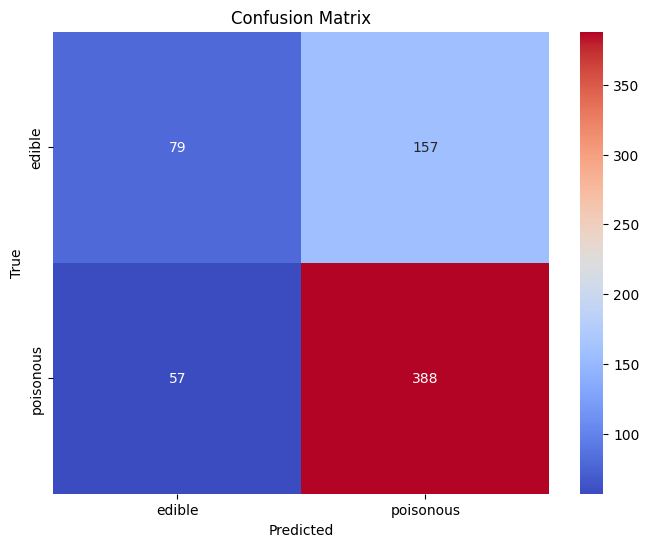

In [17]:
#heatmap visualization
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

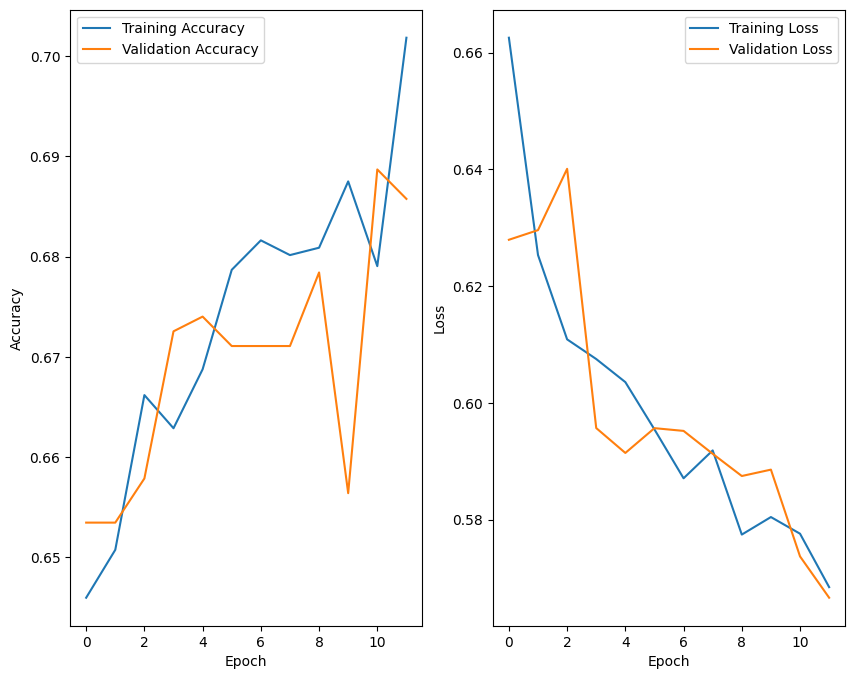

In [18]:
#plot accuracy
plt.figure(figsize=(10, 8))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


/tmp/ipython-input-1673919875.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = int(model.predict(sample_image/255.0) > 0.5)


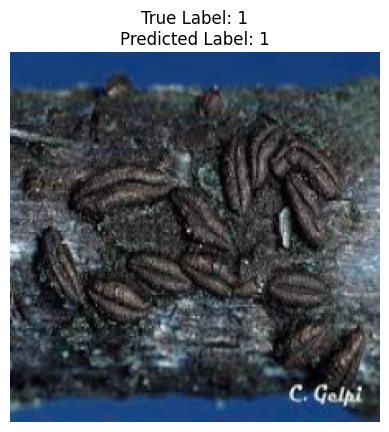

In [33]:
#load model
model = tf.keras.models.load_model('cnn_model.keras')

sample_image = images[1]
sample_label = labels[1]

sample_image = np.expand_dims(sample_image, axis=0)
prediction = int(model.predict(sample_image/255.0) > 0.5)
true_class_label = sample_label

#display
plt.imshow(sample_image[0])
plt.title(f"True Label: {true_class_label}\nPredicted Label: {prediction}")
plt.axis('off')
plt.show()

## MobileNetV2 Transfer Learning

In [ ]:
import numpy as np
import cv2
import PIL.Image as Image
import os
import matplotlib.pyplot as plt

import tensorflow as tf
import tf_keras
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

In [ ]:
IMAGE_SHAPE = (224,224)
data_folder_path = '/content/edible-and-poisonous-fungi'

images = []
labels = []

for sub in os.listdir(data_folder_path):
  file_path = os.path.join(data_folder_path, sub)
  for file in os.listdir(file_path):
    img_path = os.path.join(file_path, file)
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, IMAGE_SHAPE)
      images.append(resized)
      if sub.startswith('edible'):
        labels.append(0)
      elif sub.startswith('poisonous'):
        labels.append(1)

images = np.array(images)
labels = np.array(labels) ## 0=edible 1=poisonous

In [ ]:
#distribution classes
print('Total: ', len(labels))
print('Edible: ', len(labels[labels==0]))
print('Poisonous: ', len(labels[labels==1]))

Total:  3401
Edible:  1181
Poisonous:  2220


In [ ]:
#split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

#normalizing
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

In [ ]:
base = MobileNetV2(
    input_shape=IMAGE_SHAPE+(3,),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = Sequential()
model.add(base)
model.add(GlobalAveragePooling2D())
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=10, batch_size=32)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 205ms/step - accuracy: 0.6188 - loss: 0.6765 - val_accuracy: 0.7416 - val_loss: 0.5167
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7364 - loss: 0.5281 - val_accuracy: 0.7533 - val_loss: 0.4971
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7540 - loss: 0.4936 - val_accuracy: 0.7709 - val_loss: 0.4700
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7852 - loss: 0.4589 - val_accuracy: 0.7768 - val_loss: 0.4587
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7838 - loss: 0.4545 - val_accuracy: 0.7739 - val_loss: 0.4711
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7914 - loss: 0.4435 - val_accuracy: 0.7724 - val_loss: 0.4460
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8178 - loss: 0.4119 - val_accuracy: 0.7900 - val_loss: 0.4386
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8194 - loss: 0.4071 - val_accuracy: 0.7856 

In [ ]:
model.evaluate(X_test_scaled, y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7859 - loss: 0.4492


[0.4342454969882965, 0.784140944480896]

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_classes, target_names=['edible', 'poisonous']))

22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step
              precision    recall  f1-score   support

      edible       0.67      0.65      0.66       219
   poisonous       0.84      0.85      0.84       462

    accuracy                           0.78       681
   macro avg       0.75      0.75      0.75       681
weighted avg       0.78      0.78      0.78       681



In [ ]:
model.save('transfer_learning_model.keras')

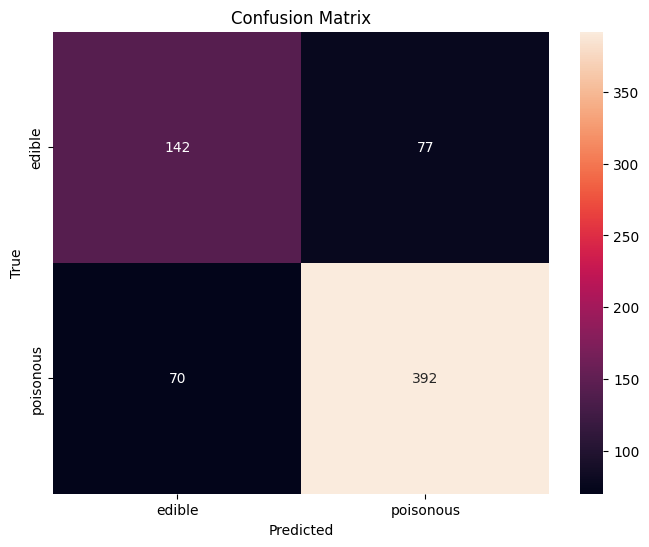

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), fmt='d', annot=True, xticklabels=['edible','poisonous'], yticklabels=['edible','poisonous'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()